# 02 — Preprocessing: Masks → YOLO Segmentation Format

**Goal**: Convert raw grayscale annotation masks into YOLO segmentation polygon labels.

**Input**:
- Raw RGB images (480×360)
- Grayscale masks (pixel value = class ID)
- `audit_results.json` from Notebook 01

**Output** (`dataset/` directory):
```
dataset/
├── images/train/   ← matched training images
├── images/val/     ← 20% split from training
├── images/test/    ← test images (held out)
├── labels/train/   ← YOLO polygon .txt files
├── labels/val/
├── labels/test/
└── dataset.yaml
```

**YOLO segmentation label format** (per line in `.txt`):
```
<class_id> <x1> <y1> <x2> <y2> ... <xn> <yn>
```
All coordinates are normalized to [0, 1] relative to image width/height.

> **Prerequisite**: Run `01_data_audit.ipynb` first and update `class_names` in `audit_results.json`.

## 1. Imports & Load Audit Results

In [1]:
import numpy as np
import cv2
import json
import shutil
import yaml
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

BASE_DIR = Path("..")  # project root

# Load audit results from Notebook 01
audit_path = BASE_DIR / "audit_results.json"
assert audit_path.exists(), "Run 01_data_audit.ipynb first to generate audit_results.json"

with open(audit_path) as f:
    audit = json.load(f)

print(f"Loaded audit results from {audit_path}")
print(f"\nClass names from audit (verify these are correct):")
for pv, name in audit["class_names"].items():
    print(f"  pixel {pv:>3}  →  {name}")

Loaded audit results from ..\audit_results.json

Class names from audit (verify these are correct):
  pixel   0  →  background
  pixel   1  →  class_1
  pixel   2  →  class_2
  pixel   3  →  class_3
  pixel   4  →  class_4
  pixel   5  →  class_5
  pixel   6  →  class_6
  pixel   7  →  class_7
  pixel   8  →  class_8
  pixel   9  →  class_9
  pixel  10  →  class_10
  pixel  11  →  class_11


## 2. Class Map Configuration

⚠️ **Review this cell carefully.** `CLASS_MAP` maps pixel values → YOLO class IDs (0-indexed).
Background (pixel 0) is excluded from YOLO labels (it's the implicit negative class).

Update `CLASS_NAMES` below if you changed names in `audit_results.json`.

In [2]:
# Load class names from audit (you updated these after running notebook 01)
raw_class_names = audit["class_names"]  # {"0": "background", "1": "road", ...}

# Build CLASS_MAP: pixel_value (int) → yolo_class_id (0-indexed), excluding background
pixel_values_sorted = sorted(int(k) for k in raw_class_names if int(k) != 0)
CLASS_MAP   = {pv: idx for idx, pv in enumerate(pixel_values_sorted)}
CLASS_NAMES = [raw_class_names[str(pv)] for pv in pixel_values_sorted]
NUM_CLASSES = len(CLASS_NAMES)

# Image dimensions (from audit)
IMG_H, IMG_W = audit["image_hw"]

print("CLASS_MAP (pixel value → YOLO class ID):")
for pv, cid in CLASS_MAP.items():
    print(f"  pixel {pv}  →  YOLO class {cid}  ({CLASS_NAMES[cid]})")
print(f"\nTotal classes (excl. background): {NUM_CLASSES}")
print(f"Image size: {IMG_W}x{IMG_H}")

CLASS_MAP (pixel value → YOLO class ID):
  pixel 1  →  YOLO class 0  (class_1)
  pixel 2  →  YOLO class 1  (class_2)
  pixel 3  →  YOLO class 2  (class_3)
  pixel 4  →  YOLO class 3  (class_4)
  pixel 5  →  YOLO class 4  (class_5)
  pixel 6  →  YOLO class 5  (class_6)
  pixel 7  →  YOLO class 6  (class_7)
  pixel 8  →  YOLO class 7  (class_8)
  pixel 9  →  YOLO class 8  (class_9)
  pixel 10  →  YOLO class 9  (class_10)
  pixel 11  →  YOLO class 10  (class_11)

Total classes (excl. background): 11
Image size: 480x360


## 3. Paths & Dataset Directory Structure

In [3]:
TRAIN_IMG_DIR  = next(BASE_DIR.glob("images_prepped_train*/*"))
TRAIN_MASK_DIR = next(BASE_DIR.glob("annotations_prepped_train*/*"))
TEST_IMG_DIR   = next(BASE_DIR.glob("images_prepped_test*/*"))
TEST_MASK_DIR  = next(BASE_DIR.glob("annotations_prepped_test*/*"))

DATASET_DIR = BASE_DIR / "dataset"

# Create output directory structure
for split in ["train", "val", "test"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print(f"Dataset directory created at: {DATASET_DIR.resolve()}")

Dataset directory created at: C:\NaufalFirdaus\CODES\MyGithub\self-driving-car-yolov26\dataset


## 4. Core Conversion Functions

### How mask → polygon works:
1. Isolate each class as a binary mask
2. Find external contours with `cv2.findContours`
3. Simplify contours with `cv2.approxPolyDP` (reduces label file size)
4. Normalize coordinates to [0, 1]

In [4]:
MIN_CONTOUR_AREA  = 100   # px² — filter noise/small artifacts
MIN_POLYGON_POINTS = 3    # minimum vertices for a valid polygon
APPROX_EPSILON_FACTOR = 0.002  # contour approximation tightness (lower = more precise)


def mask_to_yolo_polygons(mask: np.ndarray, img_w: int, img_h: int) -> list[str]:
    """
    Convert a grayscale semantic mask to YOLO segmentation polygon lines.
    Returns a list of label strings, one per detected contour.
    """
    label_lines = []

    for pixel_val, class_id in CLASS_MAP.items():
        # Isolate the binary mask for this class
        binary = np.where(mask == pixel_val, 255, 0).astype(np.uint8)
        if binary.sum() == 0:
            continue  # class not present in this image

        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            if cv2.contourArea(cnt) < MIN_CONTOUR_AREA:
                continue

            # Simplify polygon
            epsilon = APPROX_EPSILON_FACTOR * cv2.arcLength(cnt, True)
            approx  = cv2.approxPolyDP(cnt, epsilon, True)

            if len(approx) < MIN_POLYGON_POINTS:
                continue

            # Normalize and flatten: [[x,y],[x,y],...] → "x y x y ..."
            pts = approx.reshape(-1, 2).astype(float)
            pts[:, 0] /= img_w
            pts[:, 1] /= img_h
            pts = pts.clip(0.0, 1.0)  # guard against border artifacts
            coords = " ".join(f"{x:.6f} {y:.6f}" for x, y in pts)
            label_lines.append(f"{class_id} {coords}")

    return label_lines


def process_pair(img_path: Path, mask_path: Path,
                 out_img_dir: Path, out_lbl_dir: Path) -> bool:
    """Process one image-mask pair and write outputs. Returns True on success."""
    mask = np.array(Image.open(mask_path).convert("L"))
    lines = mask_to_yolo_polygons(mask, IMG_W, IMG_H)

    # Copy image
    shutil.copy2(img_path, out_img_dir / img_path.name)

    # Write label file (empty file if no foreground objects)
    lbl_path = out_lbl_dir / (img_path.stem + ".txt")
    lbl_path.write_text("\n".join(lines))

    return True


print("Conversion functions defined.")
print(f"  MIN_CONTOUR_AREA  : {MIN_CONTOUR_AREA} px²")
print(f"  APPROX_EPSILON    : {APPROX_EPSILON_FACTOR} × arc length")

Conversion functions defined.
  MIN_CONTOUR_AREA  : 100 px²
  APPROX_EPSILON    : 0.002 × arc length


## 5. Train / Validation Split
Only matched pairs (image + mask) are used. Stratified random 80/20 split.

In [5]:
RANDOM_SEED = 42
VAL_RATIO   = 0.20

all_train_imgs  = sorted(TRAIN_IMG_DIR.glob("*.png"))
all_train_masks = sorted(TRAIN_MASK_DIR.glob("*.png"))

mask_stems = {p.stem: p for p in all_train_masks}
matched_pairs = [(p, mask_stems[p.stem]) for p in all_train_imgs if p.stem in mask_stems]

print(f"Matched pairs available: {len(matched_pairs)}")

train_pairs, val_pairs = train_test_split(
    matched_pairs, test_size=VAL_RATIO, random_state=RANDOM_SEED
)

print(f"Train split : {len(train_pairs)} pairs")
print(f"Val split   : {len(val_pairs)}  pairs")

Matched pairs available: 367
Train split : 293 pairs
Val split   : 74  pairs


## 6. Convert & Write Training Set

In [6]:
def process_split(pairs, split_name: str):
    out_img = DATASET_DIR / "images" / split_name
    out_lbl = DATASET_DIR / "labels" / split_name
    empty_count = 0

    for i, (img_p, msk_p) in enumerate(pairs):
        process_pair(img_p, msk_p, out_img, out_lbl)
        lbl_content = (out_lbl / (img_p.stem + ".txt")).read_text()
        if not lbl_content.strip():
            empty_count += 1
        if (i + 1) % 50 == 0 or i == len(pairs) - 1:
            print(f"  [{split_name}] {i+1}/{len(pairs)} processed", end="\r")

    print(f"  [{split_name}] Done. Empty labels: {empty_count}/{len(pairs)}")


print("Processing training set...")
process_split(train_pairs, "train")

print("Processing validation set...")
process_split(val_pairs, "val")

Processing training set...
  [train] Done. Empty labels: 0/293
Processing validation set...
  [val] Done. Empty labels: 0/74


## 7. Convert & Write Test Set

In [7]:
all_test_imgs  = sorted(TEST_IMG_DIR.glob("*.png"))
all_test_masks = sorted(TEST_MASK_DIR.glob("*.png"))
test_mask_stems = {p.stem: p for p in all_test_masks}
test_pairs = [(p, test_mask_stems[p.stem]) for p in all_test_imgs if p.stem in test_mask_stems]

print(f"Test pairs available: {len(test_pairs)}")
print("Processing test set...")
process_split(test_pairs, "test")

Test pairs available: 101
Processing test set...
  [test] Done. Empty labels: 0/101


## 8. Generate dataset.yaml
This file tells YOLO where the data lives and what the classes are.

In [8]:
dataset_yaml = {
    "path" : str(DATASET_DIR.resolve()),
    "train": "images/train",
    "val"  : "images/val",
    "test" : "images/test",
    "nc"   : NUM_CLASSES,
    "names": CLASS_NAMES,
}

yaml_path = DATASET_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, allow_unicode=True)

print(f"Saved: {yaml_path}")
print("\n--- dataset.yaml contents ---")
print(yaml_path.read_text())

Saved: ..\dataset\dataset.yaml

--- dataset.yaml contents ---
names:
- class_1
- class_2
- class_3
- class_4
- class_5
- class_6
- class_7
- class_8
- class_9
- class_10
- class_11
nc: 11
path: C:\NaufalFirdaus\CODES\MyGithub\self-driving-car-yolov26\dataset
test: images/test
train: images/train
val: images/val



## 9. Conversion Verification
Re-draw predicted polygons on the original image to confirm the conversion is correct.

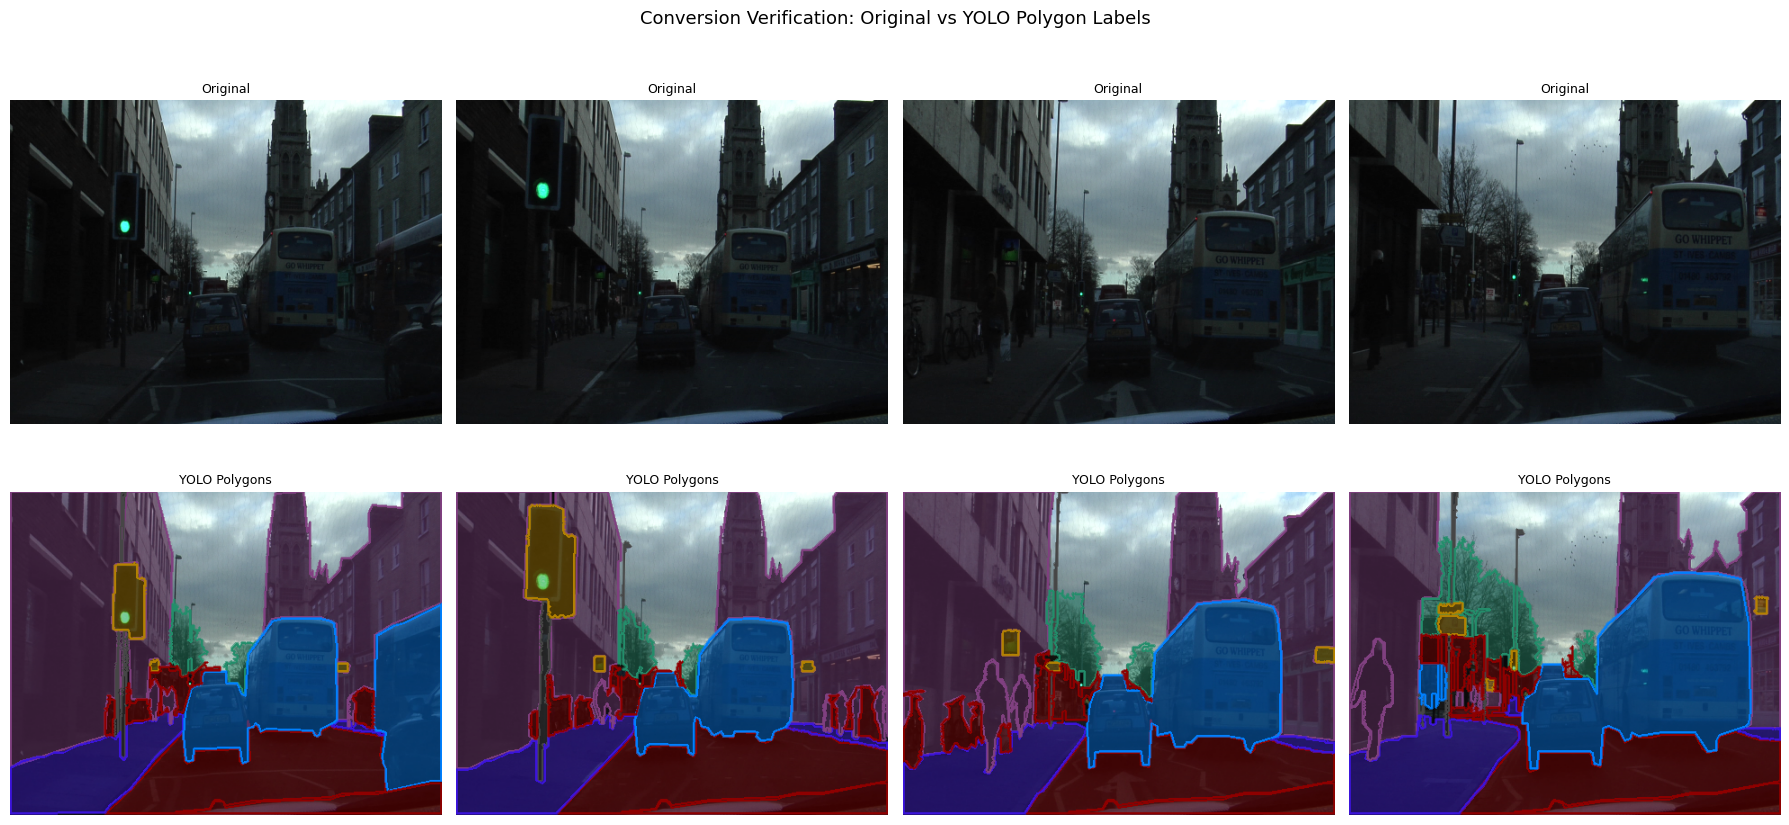

Saved: conversion_verification.png


In [9]:
PALETTE_BGR = [
    (128, 64, 128), (70, 70, 70), (142, 0, 0), (60, 20, 220),
    (35, 142, 107), (180, 130, 0), (153, 153, 190), (0, 128, 255),
]

def draw_yolo_labels(img_path: Path, lbl_path: Path) -> np.ndarray:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if not lbl_path.exists() or not lbl_path.read_text().strip():
        return img

    overlay = img.copy()
    for line in lbl_path.read_text().strip().split("\n"):
        parts = line.split()
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        pts = np.array([[coords[i]*w, coords[i+1]*h]
                        for i in range(0, len(coords), 2)], dtype=np.int32)
        color = PALETTE_BGR[cls_id % len(PALETTE_BGR)]
        cv2.fillPoly(overlay, [pts], color)
        cv2.polylines(img, [pts], True, color, 2)

    result = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)
    return result


# Show 4 verification samples from train split
train_imgs_out = sorted((DATASET_DIR / "images" / "train").glob("*.png"))[:4]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, img_path in enumerate(train_imgs_out):
    lbl_path = DATASET_DIR / "labels" / "train" / (img_path.stem + ".txt")
    original = np.array(Image.open(img_path))
    verified = draw_yolo_labels(img_path, lbl_path)

    axes[0][i].imshow(original)
    axes[0][i].set_title("Original", fontsize=9)
    axes[0][i].axis("off")

    axes[1][i].imshow(verified)
    axes[1][i].set_title("YOLO Polygons", fontsize=9)
    axes[1][i].axis("off")

plt.suptitle("Conversion Verification: Original vs YOLO Polygon Labels", fontsize=13)
plt.tight_layout()
plt.savefig("conversion_verification.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: conversion_verification.png")

## 10. Summary Statistics

In [10]:
def count_labels_in_split(split: str) -> dict:
    lbl_dir = DATASET_DIR / "labels" / split
    class_counts = {name: 0 for name in CLASS_NAMES}
    empty = 0
    for lbl in lbl_dir.glob("*.txt"):
        content = lbl.read_text().strip()
        if not content:
            empty += 1
            continue
        for line in content.split("\n"):
            cid = int(line.split()[0])
            class_counts[CLASS_NAMES[cid]] += 1
    return {"instances": class_counts, "empty_labels": empty}

for split in ["train", "val", "test"]:
    stats = count_labels_in_split(split)
    n_imgs = len(list((DATASET_DIR / "images" / split).glob("*.png")))
    print(f"\n=== {split.upper()} ({n_imgs} images) ===")
    for cls, cnt in stats["instances"].items():
        print(f"  {cls:<20} {cnt:>6} instances")
    if stats["empty_labels"]:
        print(f"  ⚠️  Empty labels: {stats['empty_labels']} (images with no foreground objects)")

print("\n✓ Preprocessing complete. Proceed to 03_training.ipynb")


=== TRAIN (293 images) ===
  class_1                1197 instances
  class_2                 807 instances
  class_3                 431 instances
  class_4                 768 instances
  class_5                 890 instances
  class_6                 902 instances
  class_7                 291 instances
  class_8                 834 instances
  class_9                 507 instances
  class_10                117 instances
  class_11               1386 instances

=== VAL (74 images) ===
  class_1                 299 instances
  class_2                 184 instances
  class_3                  97 instances
  class_4                 179 instances
  class_5                 210 instances
  class_6                 201 instances
  class_7                  56 instances
  class_8                 212 instances
  class_9                 140 instances
  class_10                 33 instances
  class_11                345 instances

=== TEST (101 images) ===
  class_1                 619 instances
